# Legal AI Hallucination Benchmark
## 03 — Model Evaluation & Error Analysis

This notebook evaluates the transparent hallucination-screening baseline developed in Notebook 02.

Because the benchmark currently contains only **11 verified cases**, this notebook does **not** train a machine-learning model or claim statistically reliable performance. Instead, it focuses on:

- threshold sensitivity;
- confusion matrices;
- false-positive and false-negative analysis;
- performance by legal domain and hallucination type;
- robustness of the screening rule; and
- practical lessons for source-grounded legal AI.

> **Responsible evaluation principle:** Small benchmark scores are illustrative, not production-grade performance estimates.


## 1. Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 220)


## 2. Load the verified evaluation benchmark

In [2]:
DATA_PATH = Path("../data/verified_benchmark_for_evaluation.csv")
df = pd.read_csv(DATA_PATH)

print(f"Cases: {len(df)}")
print(f"Supported: {(df['gold_label'] == 'Supported').sum()}")
print(f"Unsupported: {(df['gold_label'] == 'Unsupported').sum()}")
df[["case_id", "legal_domain", "gold_label", "baseline_risk_score"]]


Cases: 11
Supported: 5
Unsupported: 6


,case_id,legal_domain,gold_label,baseline_risk_score
0,v001,EU Data Protection,Supported,0
1,v002,EU Data Protection,Unsupported,4
2,v003,EU Data Protection,Unsupported,8
3,v004,Copyright & AI,Unsupported,3
4,v005,Copyright & AI,Supported,0
5,v006,Securities Regulation,Supported,0
6,v007,Securities Regulation,Unsupported,2
7,v008,Marketing & Privacy,Supported,0
8,v009,Marketing & Privacy,Unsupported,5
9,v010,Electronic Transactions,Supported,0


## 3. Evaluation metrics

For each screening threshold, the notebook calculates:

- **Accuracy** — overall share of correct classifications.
- **Precision** — among flagged claims, how many were actually unsupported.
- **Recall** — among unsupported claims, how many were flagged.
- **F1 score** — harmonic mean of precision and recall.

In legal-risk screening, recall can be important because a missed unsupported claim may be more consequential than an extra verification step. But excessive false positives can also make a system unusable.


In [3]:
def evaluate_threshold(data, threshold):
    predicted = (data["baseline_risk_score"] >= threshold).astype(int)
    gold = data["gold_hallucination"].astype(int)

    tp = ((gold == 1) & (predicted == 1)).sum()
    tn = ((gold == 0) & (predicted == 0)).sum()
    fp = ((gold == 0) & (predicted == 1)).sum()
    fn = ((gold == 1) & (predicted == 0)).sum()

    accuracy = (tp + tn) / len(data)
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall)
        else np.nan
    )

    return {
        "Threshold": threshold,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


## 4. Threshold sensitivity

In [4]:
threshold_results = pd.DataFrame(
    [evaluate_threshold(df, t) for t in range(0, 7)]
)

threshold_results[["Accuracy", "Precision", "Recall", "F1"]] = (
    threshold_results[["Accuracy", "Precision", "Recall", "F1"]].round(3)
)

threshold_results


,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,0,6,0,5,0,0.545,0.545,1.000,0.706
1,1,6,5,0,0,1.000,1.000,1.000,1.000
2,2,6,5,0,0,1.000,1.000,1.000,1.000
3,3,4,5,0,2,0.818,1.000,0.667,0.800
4,4,3,5,0,3,0.727,1.000,0.500,0.667
5,5,2,5,0,4,0.636,1.000,0.333,0.500
6,6,1,5,0,5,0.545,1.000,0.167,0.286


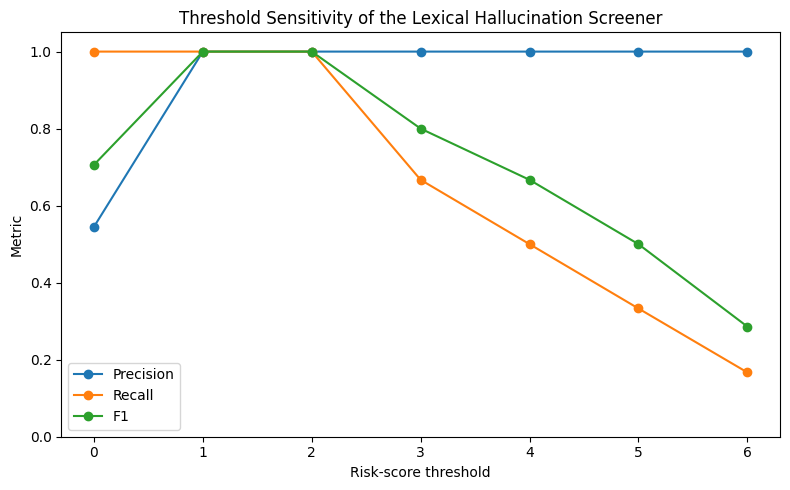

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1")
plt.title("Threshold Sensitivity of the Lexical Hallucination Screener")
plt.xlabel("Risk-score threshold")
plt.ylabel("Metric")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

A threshold that improves precision may reduce recall, and vice versa. This trade-off demonstrates why a screening threshold is a **policy choice**, not a neutral technical fact.


## 5. Evaluate the Notebook 02 default threshold

In [6]:
DEFAULT_THRESHOLD = 2

df["predicted_hallucination"] = (
    df["baseline_risk_score"] >= DEFAULT_THRESHOLD
).astype(int)

default_metrics = pd.DataFrame(
    [evaluate_threshold(df, DEFAULT_THRESHOLD)]
)

default_metrics[["Accuracy", "Precision", "Recall", "F1"]] = (
    default_metrics[["Accuracy", "Precision", "Recall", "F1"]].round(3)
)

default_metrics


,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,2,6,5,0,0,1.0,1.0,1.0,1.0


## 6. Confusion matrix

In [7]:
m = evaluate_threshold(df, DEFAULT_THRESHOLD)

confusion = pd.DataFrame(
    [[m["TN"], m["FP"]], [m["FN"], m["TP"]]],
    index=["Gold: Supported", "Gold: Unsupported"],
    columns=["Predicted: No Flag", "Predicted: Flag"]
)

confusion


,Predicted: No Flag,Predicted: Flag
Gold: Supported,5,0
Gold: Unsupported,0,6


## 7. Inspect false positives

In [8]:
false_positives = df[
    (df["gold_hallucination"] == 0) &
    (df["predicted_hallucination"] == 1)
][
    [
        "case_id", "legal_domain", "claim",
        "baseline_risk_score", "matched_risk_terms",
        "authority", "verification_note"
    ]
]

false_positives


,case_id,legal_domain,claim,baseline_risk_score,matched_risk_terms,authority,verification_note


### Why false positives matter

A supported legal proposition can still contain words like **must**, **every**, or a precise deadline. The wording may look risky even when the law actually supports it.

This means lexical intensity is useful for **triage**, but not for final legal verification.


## 8. Inspect false negatives

In [9]:
false_negatives = df[
    (df["gold_hallucination"] == 1) &
    (df["predicted_hallucination"] == 0)
][
    [
        "case_id", "legal_domain", "claim",
        "baseline_risk_score", "matched_risk_terms",
        "authority", "verification_note"
    ]
]

false_negatives


,case_id,legal_domain,claim,baseline_risk_score,matched_risk_terms,authority,verification_note


### Why false negatives matter

A legally incorrect proposition may be written in calm, professional, cautious language. If the claim contains no obvious warning phrase, a lexical model may miss it entirely.

This is the core limitation of language-only hallucination detection in legal work.


## 9. Performance by legal domain

In [10]:
domain_eval = []

for domain, group in df.groupby("legal_domain"):
    result = evaluate_threshold(group, DEFAULT_THRESHOLD)
    result["Legal_Domain"] = domain
    result["Cases"] = len(group)
    domain_eval.append(result)

domain_eval = pd.DataFrame(domain_eval)

domain_eval[
    ["Legal_Domain", "Cases", "Accuracy", "Precision", "Recall", "F1"]
].round(3)


,Legal_Domain,Cases,Accuracy,Precision,Recall,F1
0,Copyright & AI,2,1.0,1.0,1.0,1.0
1,EU Data Protection,3,1.0,1.0,1.0,1.0
2,Electronic Transactions,2,1.0,1.0,1.0,1.0
3,Marketing & Privacy,2,1.0,1.0,1.0,1.0
4,Securities Regulation,2,1.0,1.0,1.0,1.0


### Caution

Domain-level scores are especially unstable here because some domains contain only one or two examples. These results should be read as **error-inspection aids**, not comparative performance rankings.


## 10. Performance by hallucination type

In [11]:
unsupported = df[df["gold_hallucination"] == 1].copy()

type_summary = (
    unsupported.groupby("hallucination_type")
    .agg(
        Cases=("case_id", "count"),
        Average_Risk_Score=("baseline_risk_score", "mean"),
        Flagged=("predicted_hallucination", "sum")
    )
    .reset_index()
)

type_summary["Detection_Rate"] = (
    type_summary["Flagged"] / type_summary["Cases"]
).round(3)

type_summary


,hallucination_type,Cases,Average_Risk_Score,Flagged,Detection_Rate
0,Doctrinal hallucination,2,2.5,2,1.0
1,Doctrinal hallucination / overclaiming,1,4.0,1,1.0
2,Invented deadline,1,5.0,1,1.0
3,Invented fixed legal requirement,1,8.0,1,1.0
4,Scope / doctrinal hallucination,1,2.0,1,1.0


## 11. Compare lexical risk with legal correctness

In [12]:
comparison = (
    df.groupby("gold_label")
    .agg(
        Cases=("case_id", "count"),
        Mean_Lexical_Risk=("baseline_risk_score", "mean"),
        Median_Lexical_Risk=("baseline_risk_score", "median")
    )
    .reset_index()
)

comparison.round(2)


,gold_label,Cases,Mean_Lexical_Risk,Median_Lexical_Risk
0,Supported,5,0.0,0.0
1,Unsupported,6,4.0,3.5


Even if unsupported claims have a higher average lexical-risk score in this tiny benchmark, there is still overlap between classes. That overlap is exactly where legal source verification becomes necessary.


## 12. Build an evaluation error table

In [13]:
def error_category(row):
    gold = row["gold_hallucination"]
    pred = row["predicted_hallucination"]

    if gold == 1 and pred == 1:
        return "True Positive"
    if gold == 0 and pred == 0:
        return "True Negative"
    if gold == 0 and pred == 1:
        return "False Positive"
    return "False Negative"

df["evaluation_outcome"] = df.apply(error_category, axis=1)

error_table = df[
    [
        "case_id",
        "legal_domain",
        "gold_label",
        "baseline_risk_score",
        "matched_risk_terms",
        "evaluation_outcome",
        "hallucination_type",
        "authority"
    ]
].sort_values(["evaluation_outcome", "case_id"])

error_table


,case_id,legal_domain,gold_label,baseline_risk_score,matched_risk_terms,evaluation_outcome,hallucination_type,authority
0,v001,EU Data Protection,Supported,0,NaN,True Negative,NaN,GDPR Article 12(3)
4,v005,Copyright & AI,Supported,0,NaN,True Negative,NaN,"U.S. Copyright Office, Copyright and Artificial Intelligence Part 2"
5,v006,Securities Regulation,Supported,0,NaN,True Negative,NaN,"SEC guidance on officers, directors and 10% shareholders"
7,v008,Marketing & Privacy,Supported,0,NaN,True Negative,NaN,FTC CAN-SPAM compliance guide
9,v010,Electronic Transactions,Supported,0,NaN,True Negative,NaN,15 U.S.C. § 7001(a)
1,v002,EU Data Protection,Unsupported,4,"absolute, whenever",True Positive,Doctrinal hallucination / overclaiming,GDPR Article 17
2,v003,EU Data Protection,Unsupported,8,"every, exactly, universal, 30 days",True Positive,Invented fixed legal requirement,GDPR Articles 13 and 14
3,v004,Copyright & AI,Unsupported,3,"automatically, entirely",True Positive,Doctrinal hallucination,"U.S. Copyright Office, Copyright and Artificial Intelligence Part 2"
6,v007,Securities Regulation,Unsupported,2,every,True Positive,Scope / doctrinal hallucination,"SEC guidance on officers, directors and 10% shareholders"
8,v009,Marketing & Privacy,Unsupported,5,"every, 24 hours",True Positive,Invented deadline,FTC CAN-SPAM compliance guide


## 13. Human-review prioritization

In [14]:
def review_priority(row):
    if row["evaluation_outcome"] == "False Negative":
        return "Critical — missed unsupported claim"
    if row["evaluation_outcome"] == "False Positive":
        return "High — unnecessary escalation"
    if row["gold_hallucination"] == 1:
        return "High — verify authority and proposition"
    return "Routine"

df["review_priority"] = df.apply(review_priority, axis=1)

df[
    [
        "case_id",
        "gold_label",
        "evaluation_outcome",
        "review_priority"
    ]
]


,case_id,gold_label,evaluation_outcome,review_priority
0,v001,Supported,True Negative,Routine
1,v002,Unsupported,True Positive,High — verify authority and proposition
2,v003,Unsupported,True Positive,High — verify authority and proposition
3,v004,Unsupported,True Positive,High — verify authority and proposition
4,v005,Supported,True Negative,Routine
5,v006,Supported,True Negative,Routine
6,v007,Unsupported,True Positive,High — verify authority and proposition
7,v008,Supported,True Negative,Routine
8,v009,Unsupported,True Positive,High — verify authority and proposition
9,v010,Supported,True Negative,Routine


## 14. Recommended production architecture

The evaluation shows why a real legal hallucination-detection system should not rely on lexical cues alone.

A stronger architecture would use:

**1. Claim extraction**  
Identify the precise legal proposition.

**2. Jurisdiction detection**  
Determine which legal system and time period apply.

**3. Authority retrieval**  
Search statutes, regulations, cases, agency guidance, or other authoritative sources.

**4. Citation validation**  
Check whether the cited authority exists and is current.

**5. Entailment / support analysis**  
Compare the legal proposition against the retrieved authority.

**6. Confidence and escalation**  
Send uncertain or high-impact cases to human legal review.

This is closer to a real legal-research workflow than a simple text classifier.


## 15. Export evaluation results

In [15]:
OUTPUT_PATH = Path("../data/hallucination_screener_evaluation_results.csv")

df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Cases evaluated: {len(df)}")


Saved: ../data/hallucination_screener_evaluation_results.csv
Cases evaluated: 11


## Conclusions

This notebook evaluates the legal hallucination screener as a **screening control**, not as a definitive legal verifier.

### Main findings

- Model performance changes materially when the threshold changes.
- False positives arise because correct legal rules may contain categorical language.
- False negatives arise because incorrect legal claims can sound plausible and cautious.
- Domain-level results are too small for serious comparative claims.
- Legal correctness ultimately requires checking the proposition against authoritative sources.
- Error analysis provides more value than a single headline accuracy score.

### Portfolio takeaway

The project now demonstrates three layers of responsible legal-AI development:

**Benchmark audit → verified benchmark + baseline detection → evaluation + error analysis**

The next logical step is not another notebook. It is a small **interactive legal hallucination checker demo** that shows the workflow to a recruiter.
